In [1]:
import os
import json
import time
import random
from image import process_image
from ocr import run_ocr_detailed, get_easyocr_reader
from metrics import detailed_ocr_metrics, visualize_boxes
from datasets import load_dataset
from IPython.display import display

In [2]:
# point pytesseract at the local Windows install.
# guarded by os.path.exists, so it is a no-op on Chameleon / the container,
# where tesseract is already on PATH with chi_sim beside it.
_tess = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
if os.path.exists(_tess):
    os.environ.setdefault("TESSERACT_CMD", _tess)
    os.environ.setdefault("TESSDATA_PREFIX", r"C:\Users\ishan\tessdata")
print("TESSERACT_CMD =", os.environ.get("TESSERACT_CMD", "(using PATH)"))

TESSERACT_CMD = (using PATH)


In [3]:
print("--- Loading dataset 'lansinuote/ocr_id_card' ---")
try:
    ds = load_dataset("lansinuote/ocr_id_card", split='train')
    print("Dataset loaded:", len(ds), "images")
except Exception as e:
    print(f"Failed to load dataset: {e}")
    exit()

--- Loading dataset 'lansinuote/ocr_id_card' ---
Dataset loaded: 20000 images


In [4]:
with open("pipeline_configs.json") as f:
    configs = json.load(f)

[c["name"] for c in configs]

['original_tesseract',
 'original_easyocr',
 'red_tesseract',
 'red_easyocr',
 'green_tesseract',
 'green_easyocr',
 'blue_tesseract',
 'blue_easyocr',
 'bright_red_tesseract',
 'bright_red_easyocr',
 'contrast_red_green_tesseract',
 'contrast_red_green_easyocr',
 'sharpen_blue_tesseract',
 'sharpen_blue_easyocr',
 'bright_contrast_original_tesseract',
 'bright_contrast_original_easyocr']

In [5]:
# how many images to run. FULL=True runs all 20,000.
SAMPLE_SIZE = 2
SEED = 0
FULL = False

if FULL:
    indices = list(range(len(ds)))
else:
    indices = random.Random(SEED).sample(range(len(ds)), SAMPLE_SIZE)

print("running", len(indices), "images x", len(configs), "configs")

running 2 images x 16 configs


In [6]:
import torch
os.environ["EASYOCR_GPU"] = "1" if torch.cuda.is_available() else "0"
print("EASYOCR_GPU =", os.environ["EASYOCR_GPU"])

EASYOCR_GPU = 0


In [7]:
# build the EasyOCR reader once here, so its startup is not counted in any config's time
t = time.perf_counter()
get_easyocr_reader()
print(f"easyocr ready in {time.perf_counter() - t:.1f}s")

Using CPU. Note: This module is much faster with a GPU.


easyocr ready in 2.8s


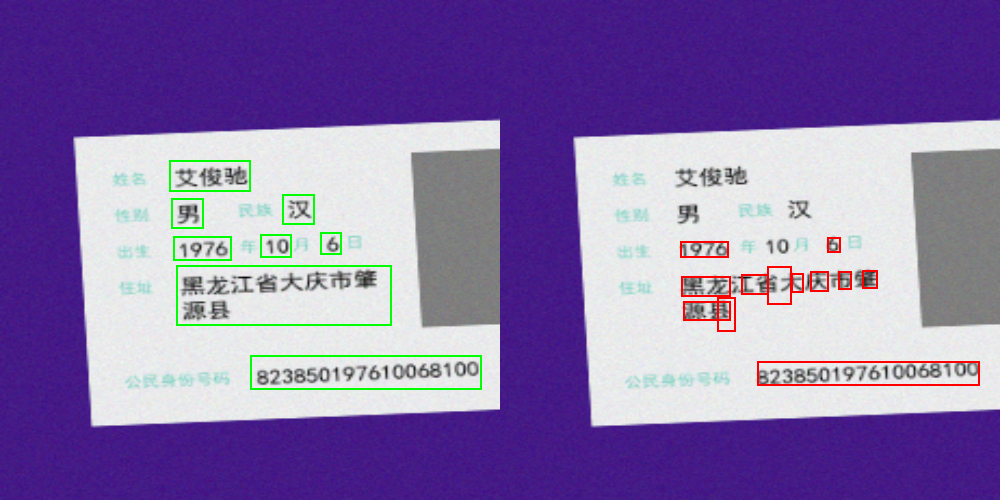

In [8]:
visual_row = ds[indices[0]]
visual_config = configs[0]
visual_image = process_image(visual_row["image"], visual_config)
visual_result = run_ocr_detailed(visual_image, visual_config["ocr"])
display(visualize_boxes(visual_row["image"], visual_row["ocr"], visual_result["detections"]))

In [9]:
rows = []
for config in configs:
    totals = {"n_fields": 0, "n_exact": 0, "n_located": 0, "n_field_exact": 0, "confidence_sum": 0.0, "confidence_count": 0}
    per_class = {}
    per_class_location = {}
    per_class_exact = {}
    start = time.perf_counter()
    for i in indices:
        row = ds[i]
        processed = process_image(row["image"], config)
        ocr_result = run_ocr_detailed(processed, config["ocr"])
        result = detailed_ocr_metrics(ocr_result, row["ocr"])
        for key in totals:
            totals[key] += result[key]
        for source, target in (("per_class", per_class), ("per_class_location", per_class_location), ("per_class_exact", per_class_exact)):
            for field, counts in result[source].items():
                accumulated = target.setdefault(field, [0, 0])
                accumulated[0] += counts[0]
                accumulated[1] += counts[1]
    elapsed = time.perf_counter() - start
    rows.append({"name": config["name"], "engine": config["ocr"], "n_images": len(indices), "n_fields": totals["n_fields"], "n_exact": totals["n_exact"], "n_located": totals["n_located"], "n_field_exact": totals["n_field_exact"], "recall": totals["n_exact"] / totals["n_fields"] if totals["n_fields"] else 0.0, "location_recall": totals["n_located"] / totals["n_fields"] if totals["n_fields"] else 0.0, "exact_field_recall": totals["n_field_exact"] / totals["n_fields"] if totals["n_fields"] else 0.0, "mean_confidence": totals["confidence_sum"] / totals["confidence_count"] if totals["confidence_count"] else None, "confidence_count": totals["confidence_count"], "mean_latency": elapsed / len(indices), "total_s": elapsed, "per_class": per_class, "per_class_location": per_class_location, "per_class_exact": per_class_exact})
    print(config["name"], rows[-1]["recall"], rows[-1]["location_recall"], rows[-1]["exact_field_recall"], rows[-1]["mean_confidence"])

original_tesseract 0.5625 0.5625 0.3125 0.5623076923076922
original_easyocr 0.5625 0.8125 0.1875 0.19224400503871547
red_tesseract 0.5 0.5625 0.25 0.6499999999999999
red_easyocr 0.625 0.625 0.125 0.21349807395190246
green_tesseract 0.625 0.375 0.1875 0.5055555555555555
green_easyocr 0.5625 0.8125 0.25 0.4102269141193232
blue_tesseract 0.625 0.75 0.4375 0.6987500000000001
blue_easyocr 0.625 0.8125 0.25 0.43332121365363807
bright_red_tesseract 0.5 0.5625 0.25 0.6538461538461537
bright_red_easyocr 0.75 0.625 0.1875 0.12752660761697074
contrast_red_green_tesseract 0.5625 0.4375 0.1875 0.7114285714285714
contrast_red_green_easyocr 0.6875 0.625 0.25 0.24984937308909794
sharpen_blue_tesseract 0.5625 0.5625 0.3125 0.5491666666666667
sharpen_blue_easyocr 0.5625 0.875 0.25 0.4518485709603354
bright_contrast_original_tesseract 0.625 0.4375 0.25 0.683888888888889
bright_contrast_original_easyocr 0.625 0.6875 0.25 0.30987697341449366


In [10]:
print(f'{"config":<28}{"engine":<11}{"text":>8}{"location":>10}{"exact":>8}{"conf":>8}{"n_conf":>9}{"s/img":>9}{"total_s":>10}')
for r in rows:
    confidence = f'{r["mean_confidence"]:.3f}' if r["mean_confidence"] is not None else 'N/A'
    print(f'{r["name"]:<28}{r["engine"]:<11}{r["recall"]:>8.3f}{r["location_recall"]:>10.3f}{r["exact_field_recall"]:>8.3f}{confidence:>8}{r["confidence_count"]:>9}{r["mean_latency"]:>9.3f}{r["total_s"]:>10.1f}')

config                      engine         text  location   exact    conf   n_conf    s/img   total_s
original_tesseract          tesseract     0.562     0.562   0.312   0.562       26    0.450       0.9
original_easyocr            easyocr       0.562     0.812   0.188   0.192       25    1.789       3.6
red_tesseract               tesseract     0.500     0.562   0.250   0.650       26    0.273       0.5
red_easyocr                 easyocr       0.625     0.625   0.125   0.213       22    1.490       3.0
green_tesseract             tesseract     0.625     0.375   0.188   0.506        9    0.231       0.5
green_easyocr               easyocr       0.562     0.812   0.250   0.410       18    1.370       2.7
blue_tesseract              tesseract     0.625     0.750   0.438   0.699       24    0.256       0.5
blue_easyocr                easyocr       0.625     0.812   0.250   0.433       17    1.358       2.7
bright_red_tesseract        tesseract     0.500     0.562   0.250   0.654       26

In [11]:
fields = ["name", "gender", "ethnicity", "birth_year", "birth_month", "birth_day", "address", "id_number"]
for r in rows:
    print(r["name"])
    for field in fields:
        text_hits, total = r["per_class"].get(field, [0, 0])
        location_hits = r["per_class_location"].get(field, [0, 0])[0]
        exact_hits = r["per_class_exact"].get(field, [0, 0])[0]
        print(f'{field:<13} text {text_hits}/{total}  location {location_hits}/{total}  exact {exact_hits}/{total}')

original_tesseract
name          text 0/2  location 1/2  exact 0/2
gender        text 1/2  location 0/2  exact 0/2
ethnicity     text 0/2  location 0/2  exact 0/2
birth_year    text 2/2  location 2/2  exact 2/2
birth_month   text 2/2  location 1/2  exact 0/2
birth_day     text 2/2  location 1/2  exact 1/2
address       text 0/2  location 2/2  exact 0/2
id_number     text 2/2  location 2/2  exact 2/2
original_easyocr
name          text 1/2  location 2/2  exact 1/2
gender        text 1/2  location 1/2  exact 0/2
ethnicity     text 0/2  location 2/2  exact 0/2
birth_year    text 2/2  location 2/2  exact 2/2
birth_month   text 2/2  location 1/2  exact 0/2
birth_day     text 2/2  location 1/2  exact 0/2
address       text 0/2  location 2/2  exact 0/2
id_number     text 1/2  location 2/2  exact 0/2
red_tesseract
name          text 0/2  location 1/2  exact 0/2
gender        text 0/2  location 0/2  exact 0/2
ethnicity     text 0/2  location 0/2  exact 0/2
birth_year    text 2/2  location 2/2  